In [10]:
import numpy as np
import matplotlib.pyplot as plt

slope = [-1.], interpret = [3.]
4.0
The SSE for the quadratic regression eqn is 1.366701518295403e-28
The SSE for the cubic regression eqn is 1.411193273349868e-26


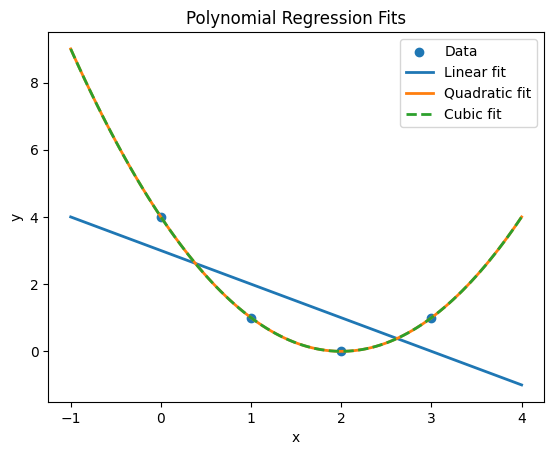

In [11]:
## =========================
## Problem
## =========================
## We are given a set of data points and want to fit models
## (linear, quadratic, cubic) using least squares.

## =========================
## Mathematical Idea
## =========================
## Least squares minimizes the sum of squared errors between the model predictions and observed data.


## =========================
## Data
## =========================
x = np.array([[0],[1],[2],[3]]) #initialize x column of toy data
y = np.array([[4],[1],[0],[1]]) #initialize y column of toy data


## =========================
## Creating Linear Model
## =========================

## Create matrix
A = np.hstack([np.ones(x.shape), x]) #creates [1, 1, 1; 0, 1, 3]

## Create pseudo-inverse
ATA = np.matmul(A.T,A)
ATAinv = np.linalg.inv(ATA)
pseudoInv = np.matmul(ATAinv,A.T)

## Find beta. Recall beta eqn is beta = (A^T * A)^-1 * A^T * y vector
beta = np.matmul(pseudoInv,y)

#best-fit values
C,D = beta
print(f"slope = {D}, interpret = {C}")

## compute the model prediction for each datapoint
model = np.matmul(A,beta)

## And the error for each datapoint
residuals = model-y

## np.squeeze converts the SSE from an array of
## shape (1,1) to a scalar with np.squeeze
SSE = np.squeeze(np.matmul(residuals.T,residuals))
print(SSE)



## =========================
## Creating Polynomial Models
## =========================

#creating matrix A for quadratic regression
A = np.hstack([np.ones(x.shape), x, x**2])

## Create pseudo-inverse
ATA = np.matmul(A.T,A)
ATAinv = np.linalg.inv(ATA)
pseudoInvA = np.matmul(ATAinv,A.T)

## Find beta. Recall beta eqn is beta = (A^T * A)^-1 * A^T * y vector
beta2A = np.matmul(pseudoInvA,y)

#best-fit values
C_1, D_1, E_1 = beta2A


#creating matrix B for cubic regression
B = np.hstack([np.ones(x.shape), x, x**2, x**3])

## Create pseudo-inverse
BTB = np.matmul(B.T,B)
BTBinv = np.linalg.inv(BTB)
pseudoInvB = np.matmul(BTBinv,B.T)

## Find beta.
beta2B = np.matmul(pseudoInvB,y)

#best-fit values
C_2, D_2, E_2, F_2 = beta2B


## =========================
## Calculating SSE for quadratic and cubic models
## =========================

### Quadratic Regression
## compute the model prediction for each datapoint
model = np.matmul(A,beta2A)

## And the error for each datapoint
residuals = model-y

## np.squeeze converts the SSE from an array of
## shape (1,1) to a scalar with np.squeeze
SSE = np.squeeze(np.matmul(residuals.T,residuals))
print(f"The SSE for the quadratic regression eqn is {SSE}")

### Cubic Regression
## compute the model prediction for each datapoint
model = np.matmul(B,beta2B)

## And the error for each datapoint
residuals = model-y

## np.squeeze converts the SSE from an array of
## shape (1,1) to a scalar with np.squeeze
SSE = np.squeeze(np.matmul(residuals.T,residuals))
print(f"The SSE for the cubic regression eqn is {SSE}")

## =========================
## Plotting Models
## =========================

plot_domain = np.linspace(-1,4,100) #set a random set of x values

y_linear_plot = C + D*plot_domain
y_quad_plot = C_1 + D_1*plot_domain + E_1*plot_domain**2
y_cubic_plot = C_2 + D_2*plot_domain + E_2*plot_domain**2 + F_2*plot_domain**3

plt.scatter(x, y, label="Data")

plt.plot(plot_domain, y_linear_plot, label="Linear fit", linewidth = 2)
plt.plot(plot_domain, y_quad_plot, label="Quadratic fit", linewidth = 2)
plt.plot(plot_domain, y_cubic_plot, label="Cubic fit", linewidth = 2, linestyle="--")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression Fits")
plt.legend()

plt.show()


## =========================
## Interpretation
## =========================
# The cubic model achieves the lowest SSE, meaning it fits the data best.
# However, higher-degree models may overfit small datasets.

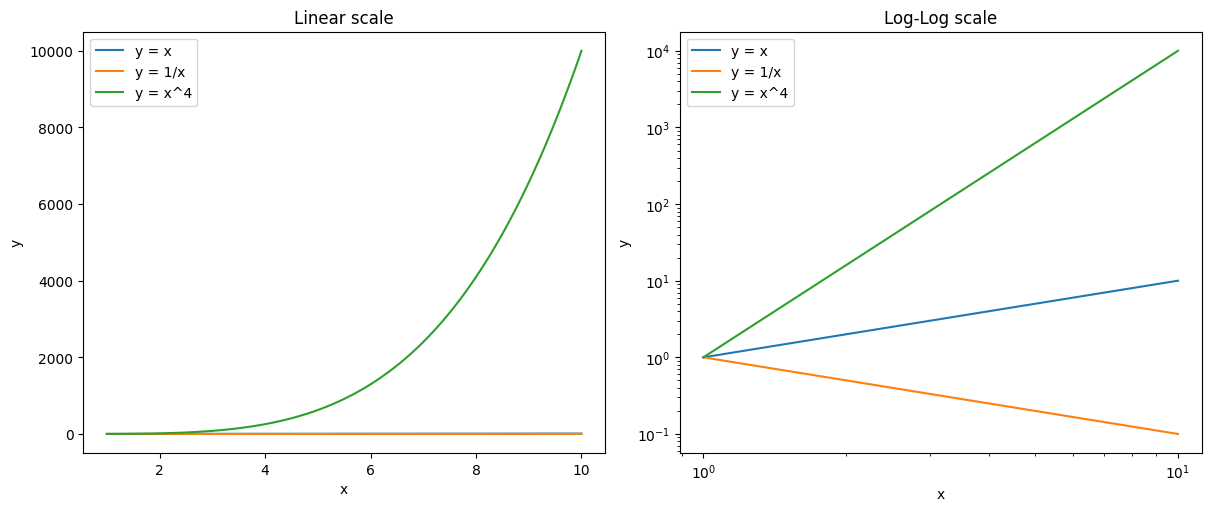

In [12]:
## ============================================================
## LOG-LOG SCALING
## ============================================================

## =========================
## Problem
## =========================
# Compare y = x, y = 1/x, y = x^4 on linear vs log-log scales.

## =========================
## Mathematical Idea
## =========================
# Power laws become linear in log-log scale:
# y = x^k → log(y) = k log(x)


## =========================
## Implementation
## =========================
x = np.linspace(1, 10, 100) #domain of plot

y1 = x      # y = x
y2 = 1/x    # y = 1/x
y3 = x**4   # y = x^4

fig, axs = plt.subplots(1,2, figsize=(12,5), layout="constrained")

# Linear scale
axs[0].plot(x, y1, label="y = x")
axs[0].plot(x, y2, label="y = 1/x")
axs[0].plot(x, y3, label="y = x^4")
axs[0].set_title("Linear scale")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].legend()

# Log-log scale
axs[1].loglog(x, y1, label="y = x")
axs[1].loglog(x, y2, label="y = 1/x")
axs[1].loglog(x, y3, label="y = x^4")
axs[1].set_title("Log-Log scale")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].legend()


## =========================
## Interpretation
## =========================
# On the log-log plot, the functions become straight lines.
# Their slopes match their exponents:
# y = x → slope 1
# y = 1/x → slope -1
# y = x^4 → slope 4


The value of S3 is: 0.75
The value of S6 is: 0.8571428571428572
The value of S10 is: 0.9090909090909091
The value of S20 is: 0.9523809523809522
The value of S100 is: 0.9900990099009898
In the linear equation log10(|sN-1|) = log10(a) + r*log10(1/N),
a = [0.9218164] and r = [0.99129454]


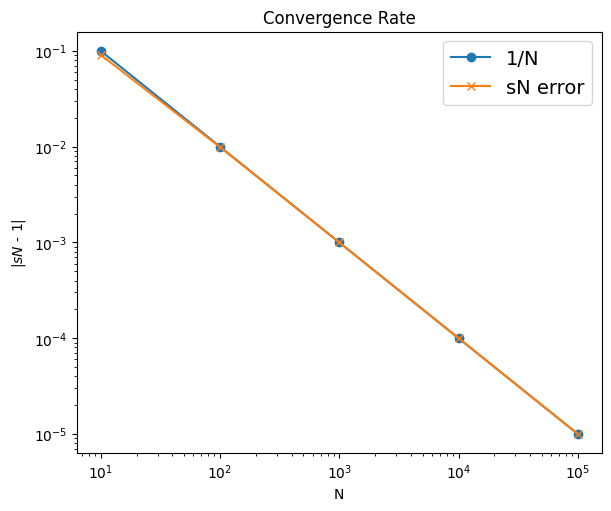

In [13]:
## ============================================================
## CONVERGENCE RATE ANALYSIS
## ============================================================

## =========================
## Problem
## =========================
# Estimate convergence rate of a series using least squares.

## =========================
## Mathematical Idea
## =========================
# If error behaves like:
# |s_N - L| ≈ a * (1/N)^r
#
# Then:
# log10(|s_N - L|) = log10(a) + r log10(1/N)


## =========================
## Implementation
## =========================

# Defining a function f as the function to be used in our summation
def f(x): #start of function
  return 1/(x*(x+1)) #return series
#end of function

# Defining a function to compute the partial sum up to n terms
def partialSum(f, n): #start of function
  sum_ = 0 #initialize sum variable

  #use for loop to incerment sum variable
  for i in range(1, n+1): #start of for loop
    sum_ += f(i) #increment sum variable with f(x)
  #end of for loop
  return sum_  #return fully incremented sum
#end of for loop

# Show that the sum is converging to 1
sThree = partialSum(f, 3)
print(f"The value of S3 is: {sThree}")
sSix = partialSum(f, 6)
print(f"The value of S6 is: {sSix}")
sTen = partialSum(f, 10)
print(f"The value of S10 is: {sTen}")
sTwenty = partialSum(f, 20)
print(f"The value of S20 is: {sTwenty}")
sHundred = partialSum(f, 100)
print(f"The value of S100 is: {sHundred}")


## =========================
## Convergence Plot
## =========================
num_Ns = np.logspace(1,5,5,dtype=int) #create array of 10, 100, 1000, 10000 and 100000

error_list = [] #initialize error list
invN = [] #initalize list of inverse N values

#use for loop to append items to each list
for N in num_Ns: #start of for loop
  sN = partialSum(f,N) #use partialSum function created earlier
  error_list.append(abs(sN - 1.0)) #add to error list
  invN.append(1.0/N) #add to inverse N list
#end of for loop

#plotting
plt.figure(figsize=(6,5), layout="constrained")

#use loglog for scaling purposes
plt.loglog(num_Ns, invN,"o-",label="1/N")
plt.loglog(num_Ns,error_list, "x-", label="sN error")


plt.legend(fontsize = 14)
plt.xlabel("N")
plt.ylabel("|$sN$ - 1|")
plt.title("Convergence Rate")


## =========================
## Linearization + Least Squares
## =========================
log_invN = np.log10(invN)       # Take log base 10 of 1/N to linearize the power-law relationship
log_error_list = np.log10(error_list)  # Take log base 10 of |s_N - 1|, same reason
xlog = log_invN.T               # transpose to make it a row vector (optional, depending on shape)
slog = log_error_list.T          # transpose error array similarly
xcol = xlog[:,None]             # convert xlog to a column vector (shape: Nx1)
scol = slog[:,None]             # convert slog to a column vector

D = np.hstack([np.ones(xcol.shape), xcol])   # Create design matrix with a column of ones and xcol
DTD = np.matmul(D.T,D)          # Compute D^T * D, part of the pseudoinverse formula
DTDinv = np.linalg.inv(DTD)     # Take the inverse of D^T * D
pInv= np.matmul(DTDinv,D.T)     # Multiply by D^T to get the pseudoinverse
Dbeta = np.matmul(pInv,scol)   # Multiply pseudoinverse by the log-error vector to get beta
alog,r = Dbeta                  # Unpack the intercept and slope
a = 10**alog                    # Convert intercept back from log scale to original a

#print results
print(f"In the linear equation log10(|sN-1|) = log10(a) + r*log10(1/N),")
print(f"a = {a} and r = {r}")

## =========================
## Interpretation
## =========================
# The estimated convergence rate r ≈ 1
# This indicates first-order convergence:
# error decreases proportionally to 1/N